<a href="https://colab.research.google.com/github/jpnoug/spectropy/blob/main/Analyse_image_spectre_2D_en_longueur_d'onde_et_arcsec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- 1. Installation des dépendances ---
!pip install astropy -q

In [ ]:
# --- 2. Import des bibliothèques ---
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from google.colab import files
from scipy.interpolate import interp1d

In [ ]:
# --- 3. Upload du fichier FITS ---
print("Sélectionner le fichier fits 2D _objet issu du traitement Isis  :")
uploaded = files.upload()
fits_file = list(uploaded.keys())[0]



Sélectionner le fichier fits 2D _objet issu du traitement Isis  :


Saving _M1_nuit2.fit to _M1_nuit2.fit


In [ ]:
# --- 4. Polynôme de calibration ISIS (Alpy 600) ---
A0 =  2890.605
A1 =  3.3178208
A2 =  0.0006049546
A3 = -5.154625e-07
A4 =  1.132926e-10

def pixel_to_wavelength(x):
    return A0 + A1*x + A2*x**2 + A3*x**3 + A4*x**4

In [ ]:
# --- 5. Chargement de l'image FITS ---
with fits.open(fits_file) as hdul:
    image = hdul[0].data

ny, nx = image.shape
print(f"Dimensions : {image.shape}")

Dimensions : (1039, 1391)


In [ ]:
# --- 6. Axe spectral non linéaire ---
pixels = np.arange(nx)
wavelengths = pixel_to_wavelength(pixels)

In [ ]:
# --- 7. Axe spatial ---

arcsec_per_pixel = 1.478 # Echelle d'image (arcsec/pixel) = (Taille du pixel (microns) / Focale (mm)) * 206265

# center_row = ny // 2

# --- 8. Rééchantillonnage sur axe linéaire ---
wl_lin = np.linspace(wavelengths[0], wavelengths[-1], nx)

image_resampled = np.zeros_like(image)

for i in range(ny):
    f = interp1d(wavelengths, image[i,:],
                 kind='linear',
                 bounds_error=False,
                 fill_value=0)
    image_resampled[i,:] = f(wl_lin)

# Profil spatial (intensité le long de la fente)
profil_spatial = np.sum(image_resampled, axis=1)

# Position du maximum = centre de la nébuleuse
center_row = np.argmax(profil_spatial)

print(f"Centre détecté (pixel Y) : {center_row}")

# Nouvel axe Y centré
arcsec = (np.arange(ny) - center_row) * arcsec_per_pixel


Centre détecté (pixel Y) : 470


In [ ]:
# --- 8. Rééchantillonnage sur axe linéaire ---
wl_lin = np.linspace(wavelengths[0], wavelengths[-1], nx)

image_resampled = np.zeros_like(image)

for i in range(ny):
    f = interp1d(wavelengths, image[i,:],
                 kind='linear',
                 bounds_error=False,
                 fill_value=0)
    image_resampled[i,:] = f(wl_lin)

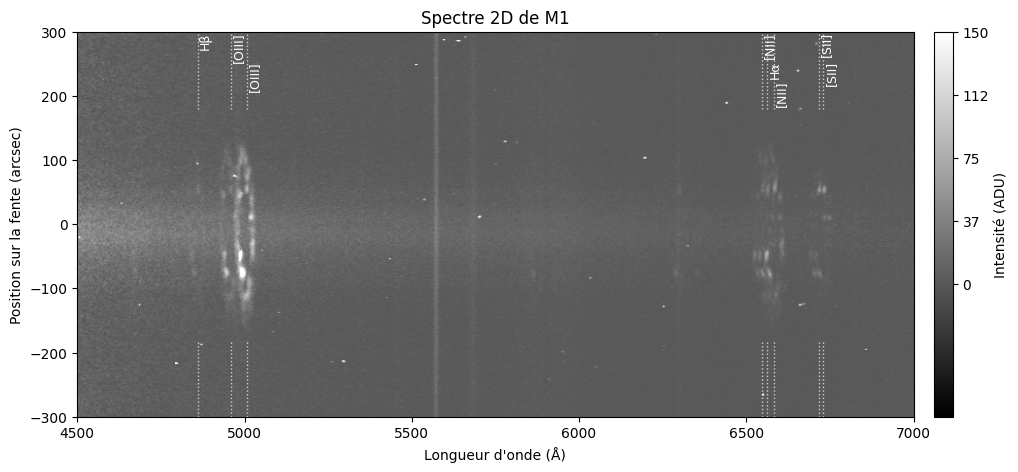

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- 9. Affichage ---
fig, ax = plt.subplots(figsize=(13,5))

vmin, vmax = np.percentile(image_resampled, [10,99.5])
# percentile = auto-contraste robuste; valeurs typiques [5, 99] → bon compromis [10, 99.5] → plus punchy

extent = [wl_lin[0], wl_lin[-1], arcsec[0], arcsec[-1]]

im = ax.imshow(
    image_resampled,
    origin='lower',
    aspect='auto',
    extent=extent,
    cmap='gray',
    vmin=vmin,
    vmax=vmax
)

# --- Zoom spectral & spatial ---
ax.set_xlim(4500, 7000)
ax.set_ylim(-300, 300)

# --- Raies principales ---
raies = {
    "Hβ": 4861.33,
    "[OIII]": 4958.91,
    "[OIII] ": 5006.84,
    "Hα": 6562.80,
    "[NII]": 6548.05,
    "[NII] ": 6583.45,
    "[SII]": 6716.44,
    "[SII] ": 6730.82,
}

# Tri par longueur d’onde
raies_triees = sorted(raies.items(), key=lambda x: x[1])

# Niveaux verticaux pour labels
levels = [1, 0.85, 0.75, 0.65]

last_lam = None
level = 0

ymin, ymax = ax.get_ylim()
dy = (ymax - ymin) * 0.2  # segments 20% hauteur

for nom, lam in raies_triees:
    if 3800 < lam < 7000:

        # anti-chevauchement vertical
        if last_lam is not None and abs(lam - last_lam) < 80:
            level += 1
        else:
            level = 0

        y = ymax * levels[level % len(levels)]

        # segments blanc en haut et bas
        ax.plot([lam, lam], [ymin, ymin + dy], color='white', linestyle=':', linewidth=1, alpha=0.7)
        ax.plot([lam, lam], [ymax - dy, ymax], color='white', linestyle=':', linewidth=1, alpha=0.7)

        # label blanc
        ax.text(lam + 3, y, nom.strip(),
                color='white',
                fontsize=9,
                rotation=90,
                va='top',
                ha='left')

        last_lam = lam

ax.set_xlabel("Longueur d'onde (Å)")
ax.set_ylabel("Position sur la fente (arcsec)")
ax.set_title("Spectre 2D de M1")

# --- Colorbar ADU ---
cbar = fig.colorbar(im, ax=ax, pad=0.02)
ticks = np.linspace(0, vmax, 5)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t)}" for t in ticks])
cbar.set_label("Intensité (ADU)")

# --- Sauvegarde ---
output_name = "spectre_2D_final.png"
fig.savefig(output_name, dpi=300, bbox_inches='tight')

# --- Affichage ---
plt.show()

# --- Téléchargement ---
from google.colab import files
files.download(output_name)

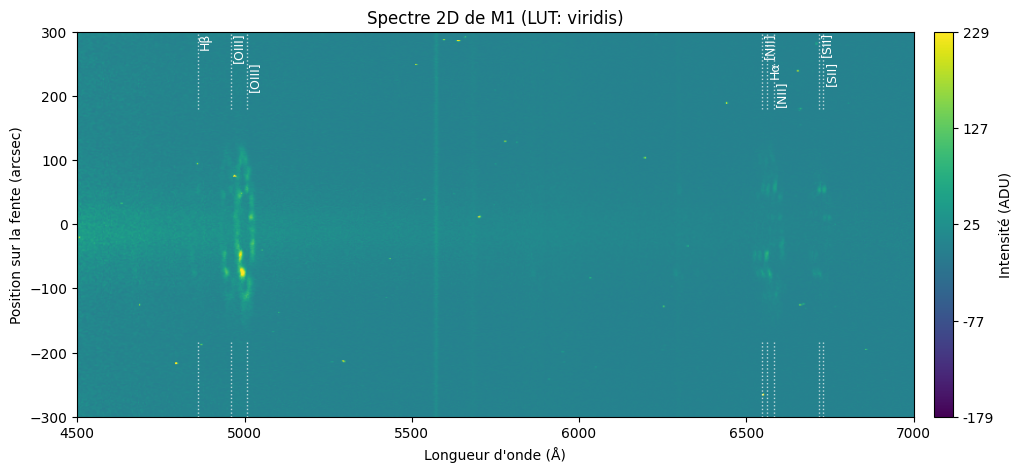

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

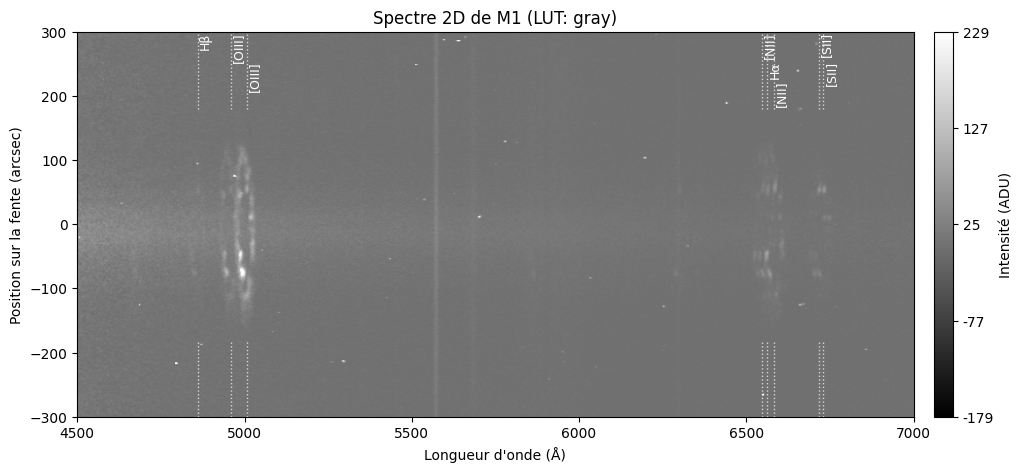

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

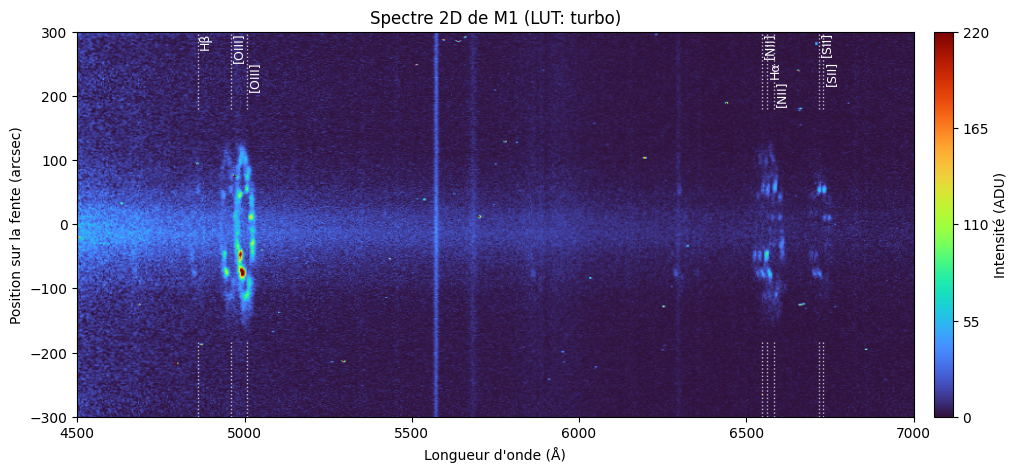

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# --- 9.1 Affichage avec fausses couleurs et contraste ajusté (nouvelle visualisation) ---

# Liste des cartes de couleurs à essayer
colormaps = ['viridis', 'gray', 'turbo']

for cmap_name in colormaps:
    fig, ax = plt.subplots(figsize=(13,5))

    # Ajustement des percentiles pour un contraste plus marqué
    # Pour 'turbo', ajuster spécifiquement pour que le fond soit bleu et le max soit rouge
    if cmap_name == 'turbo':
        vmin_plot = 0 # ADU pour le bleu
        vmax_plot = 220 # ADU pour le rouge
    else:
        vmin_plot = np.percentile(image_resampled, 1)
        vmax_plot = np.percentile(image_resampled, 99.9) # vmax reste le 99.9e percentile

    extent = [wl_lin[0], wl_lin[-1], arcsec[0], arcsec[-1]]

    im = ax.imshow(
        image_resampled,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap=cmap_name, # Changement dynamique de la carte de couleurs (LUT)
        vmin=vmin_plot,
        vmax=vmax_plot
    )

    # --- Zoom spectral & spatial ---
    ax.set_xlim(4500, 7000)
    ax.set_ylim(-300, 300)

    # --- Raies principales ---
    raies = {
        "Hβ": 4861.33,
        "[OIII]": 4958.91,
        "[OIII] ": 5006.84,
        "Hα": 6562.80,
        "[NII]": 6548.05,
        "[NII] ": 6583.45,
        "[SII]": 6716.44,
        "[SII] ": 6730.82,
    }

    # Tri par longueur d’onde
    raies_triees = sorted(raies.items(), key=lambda x: x[1])

    # Niveaux verticaux pour labels
    levels = [1, 0.85, 0.75, 0.65]

    last_lam = None
    level = 0

    ymin, ymax = ax.get_ylim()
    dy = (ymax - ymin) * 0.2  # segments 20% hauteur

    for nom, lam in raies_triees:
        if 3800 < lam < 7000:

            # anti-chevauchement vertical
            if last_lam is not None and abs(lam - last_lam) < 80:
                level += 1
            else:
                level = 0

            y = ymax * levels[level % len(levels)]

            # segments blanc en haut et bas
            ax.plot([lam, lam], [ymin, ymin + dy], color='white', linestyle=':', linewidth=1, alpha=0.7)
            ax.plot([lam, lam], [ymax - dy, ymax], color='white', linestyle=':', linewidth=1, alpha=0.7)

            # label blanc
            ax.text(lam + 3, y, nom.strip(),
                    color='white',
                    fontsize=9,
                    rotation=90,
                    va='top',
                    ha='left')

            last_lam = lam

    ax.set_xlabel("Longueur d'onde (Å)")
    ax.set_ylabel("Position sur la fente (arcsec)")
    ax.set_title(f"Spectre 2D de M1 (LUT: {cmap_name})")

    # --- Colorbar ADU ---
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    ticks = np.linspace(vmin_plot, vmax_plot, 5)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{int(t)}" for t in ticks]) # Corrected indentation
    cbar.set_label("Intensité (ADU)") # Corrected indentation

    # --- Sauvegarde ---
    output_name_fc = f"spectre_2D_final_{cmap_name}.png"
    fig.savefig(output_name_fc, dpi=300, bbox_inches='tight')

    # --- Affichage ---
    plt.show()

    # --- Téléchargement ---
    from google.colab import files
    files.download(output_name_fc)


Analyse de la raie détectée 1 (approx. 5022.84 Å):
    Position mesurée de la Raie 1 (détectée) : 5022.831 Å
    Largeur (sigma) de la Raie 1 (détectée) : 5.559 Å


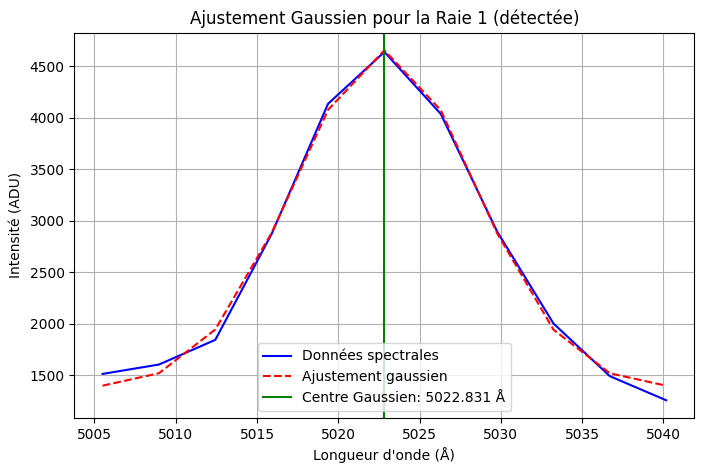


Analyse de la raie détectée 2 (approx. 4984.70 Å):
    Position mesurée de la Raie 2 (détectée) : 4982.056 Å
    Largeur (sigma) de la Raie 2 (détectée) : 8.186 Å


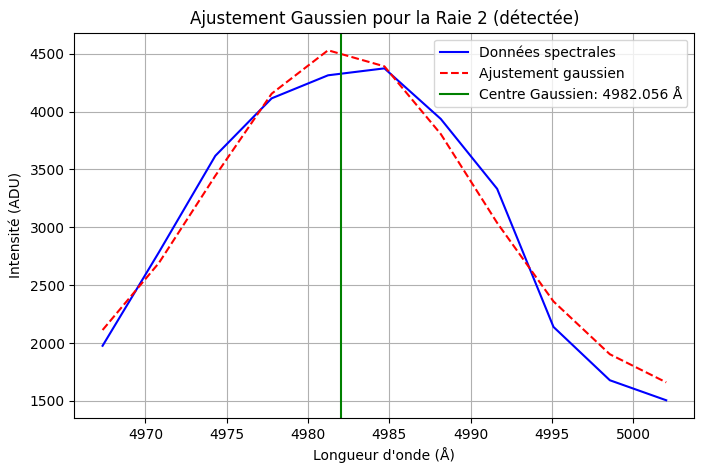


Analyse de la raie détectée 3 (approx. 4936.16 Å):
    Position mesurée de la Raie 3 (détectée) : 4936.781 Å
    Largeur (sigma) de la Raie 3 (détectée) : 6.593 Å


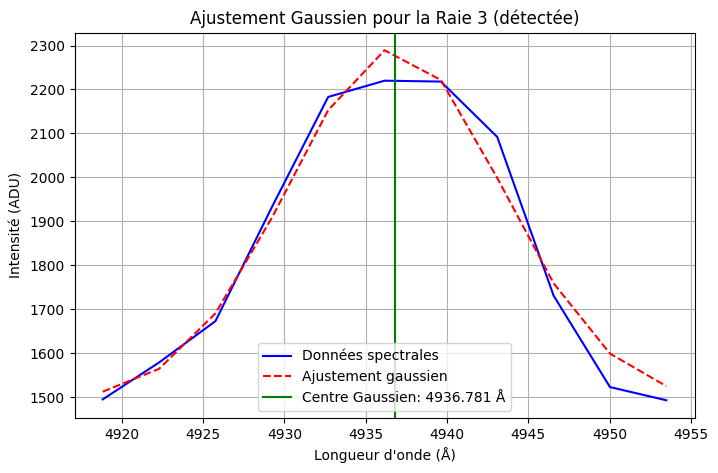


Positions mesurées des raies en émission :
Raie 1 (détectée): 5022.831 Å
Raie 2 (détectée): 4982.056 Å
Raie 3 (détectée): 4936.781 Å


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks # New import for peak detection

# --- 10. Calcul du profil spectral entre -50 et +50 arcsec ---

# Trouver les indices correspondant à la plage spatiale désirée (-50 à +50 arcsec)
idx_min = np.argmin(np.abs(arcsec - (-50)))
idx_max = np.argmin(np.abs(arcsec - (50)))

# Extraire la portion de l'image resampled
image_subregion = image_resampled[idx_min:idx_max+1, :]

# Calculer le profil spectral (somme sur l'axe spatial de la subregion)
profil_spectral = np.sum(image_subregion, axis=0)

# --- 11. Mesure des raies en émission par ajustement gaussien (sans position théorique) ---

# Fonction gaussienne
def gaussian(x, amplitude, mean, sigma, offset):
    return amplitude * np.exp(-(x - mean)**2 / (2 * sigma**2)) + offset

# Plage de recherche des raies (autour de 5000 Å comme demandé)
search_min_wl = 4800 # Min wavelength for peak search
search_max_wl = 5200 # Max wavelength for peak search, slightly wider for OIII doublet
search_mask = (wl_lin > search_min_wl) & (wl_lin < search_max_wl)
search_x_data = wl_lin[search_mask]
search_y_data = profil_spectral[search_mask]

# Trouver les pics dans cette région
# 'prominence' aide à filtrer les petits bruits. La valeur peut être ajustée.
# 'width' (largeur minimale des pics) peut aussi être ajustée.
peaks_indices, properties = find_peaks(search_y_data, prominence=np.max(search_y_data)*0.1, width=2)

# Si aucun pic n'est trouvé
if len(peaks_indices) == 0:
    print(f"Aucun pic significatif trouvé entre {search_min_wl} et {search_max_wl} Å.")
else:
    # Trier les pics par intensité (amplitude) et prendre les 3 plus intenses
    peak_heights = properties['width_heights']
    # Map the indices from search_y_data back to wl_lin
    original_indices = np.where(search_mask)[0][peaks_indices]
    peak_wavelengths_detected = wl_lin[original_indices]

    # Create a list of (height, wavelength, original_index_in_wl_lin) for sorting
    peaks_info = []
    for i in range(len(peak_heights)):
        peaks_info.append((peak_heights[i], peak_wavelengths_detected[i], original_indices[i]))

    sorted_peaks_info = sorted(peaks_info, key=lambda x: x[0], reverse=True)

    measured_emission_lines = {}
    num_lines_to_fit = min(3, len(sorted_peaks_info)) # Fit up to 3 most intense lines

    for i in range(num_lines_to_fit):
        peak_height, peak_wavelength, _ = sorted_peaks_info[i]

        print(f"\nAnalyse de la raie détectée {i+1} (approx. {peak_wavelength:.2f} Å):")

        # Définir une fenêtre de données autour du pic détecté pour l'ajustement
        fit_window_half = 20 # Å, adjust as needed based on expected line width
        fit_mask = (wl_lin > peak_wavelength - fit_window_half) & (wl_lin < peak_wavelength + fit_window_half)
        x_data_fit = wl_lin[fit_mask]
        y_data_fit = profil_spectral[fit_mask]

        if len(x_data_fit) < 4: # Need at least 4 points for 4 parameters
            print(f"    Pas assez de points de données pour ajuster la raie autour de {peak_wavelength:.2f} Å. Saute.")
            continue

        # Estimation des paramètres initiaux pour l'ajustement
        mean_guess = peak_wavelength # Use the detected peak wavelength as initial mean

        # offset_guess: estimate from the lowest 10% of values in the fit window
        sorted_y_data_fit = np.sort(y_data_fit)
        offset_guess = np.mean(sorted_y_data_fit[:max(1, int(len(sorted_y_data_fit) * 0.1))])

        amplitude_guess = np.max(y_data_fit) - offset_guess
        if amplitude_guess <= 0: # Ensure positive amplitude for emission lines
            amplitude_guess = np.max(y_data_fit) - np.min(y_data_fit)
            if amplitude_guess <= 0:
                amplitude_guess = 1.0 # Fallback to a small positive value

        sigma_guess = 5.0 # Reasonable initial guess for sigma (Å)

        p0 = [amplitude_guess, mean_guess, sigma_guess, offset_guess]

        # Définition des bornes pour les paramètres
        # amplitude > 0, mean dans la fenêtre de fit, sigma > 0.1, offset >= 0
        lower_bounds = [0, x_data_fit.min(), 0.1, np.min(y_data_fit)] # offset can't be below data min
        upper_bounds = [np.inf, x_data_fit.max(), fit_window_half, np.max(y_data_fit)] # sigma max is fit window size

        try:
            popt, pcov = curve_fit(gaussian, x_data_fit, y_data_fit, p0=p0, bounds=(lower_bounds, upper_bounds), maxfev=10000)
            amplitude, mean, sigma, offset = popt

            line_name = f"Raie {i+1} (détectée)"
            measured_emission_lines[line_name] = mean

            print(f"    Position mesurée de la {line_name} : {mean:.3f} Å")
            print(f"    Largeur (sigma) de la {line_name} : {sigma:.3f} Å")

            # --- Affichage de l'ajustement ---
            plt.figure(figsize=(8, 5))
            plt.plot(x_data_fit, y_data_fit, 'b-', label='Données spectrales')
            plt.plot(x_data_fit, gaussian(x_data_fit, *popt), 'r--', label='Ajustement gaussien')
            plt.axvline(mean, color='g', linestyle='-', label=f'Centre Gaussien: {mean:.3f} Å')
            plt.title(f'Ajustement Gaussien pour la {line_name}')
            plt.xlabel("Longueur d'onde (Å)")
            plt.ylabel("Intensité (ADU)")
            plt.legend()
            plt.grid(True)
            plt.show()

        except RuntimeError:
            print(f"    L'ajustement gaussien n'a pas pu converger pour la raie autour de {peak_wavelength:.2f} Å.")
        except ValueError as e:
            print(f"    Erreur lors de l'ajustement pour la raie autour de {peak_wavelength:.2f} Å: {e}")

    print("\nPositions mesurées des raies en émission :")
    for name, wavelength in measured_emission_lines.items():
        print(f"{name}: {wavelength:.3f} Å")

In [ ]:
# --- 12. Calcul des vitesses Doppler ---

# Vitesse de la lumière en km/s
c = 299792.458 # km/s

# Récupérer les longueurs d'onde mesurées
# Note: L'ordre ici est basé sur l'ordre de détection, qui correspond à notre interprétation
# Raie 1 (approx 5022.831 Å) - la plus red-shifted de OIII 5007
# Raie 2 (approx 4982.056 Å) - composante blue-shifted de OIII 5007 ET red-shifted de OIII 4959
# Raie 3 (approx 4936.781 Å) - la plus blue-shifted de OIII 4959
measured_wavelengths = list(measured_emission_lines.values())
# Ensure consistent mapping if the order of detected lines can change
# For robust mapping, one might want to match to theoretical values with a tolerance.
# For now, we assume the user's interpretation directly maps to measured_lambda_1, 2, 3 as ordered.
measured_lambda_1 = measured_wavelengths[0]
measured_lambda_2 = measured_wavelengths[1]
measured_lambda_3 = measured_wavelengths[2]

print("\n--- Calculs de vitesse Doppler ---")
print(f"Longueurs d'onde mesurées: Raie 1={measured_lambda_1:.3f} Å, Raie 2={measured_lambda_2:.3f} Å, Raie 3={measured_lambda_3:.3f} Å")

# --- Scénario 1: Raie au repos = moyenne des deux raies composantes du dédoublement ---

print("\nScénario 1: Raie au repos = moyenne des deux raies composantes du dédoublement")

# Dédoublement des raies 1 et 2
lambda_rest_avg_1_2 = (measured_lambda_1 + measured_lambda_2) / 2
delta_lambda_1_avg_1_2 = measured_lambda_1 - lambda_rest_avg_1_2
delta_lambda_2_avg_1_2 = measured_lambda_2 - lambda_rest_avg_1_2
v_doppler_1_avg_1_2 = c * (delta_lambda_1_avg_1_2 / lambda_rest_avg_1_2)
v_doppler_2_avg_1_2 = c * (delta_lambda_2_avg_1_2 / lambda_rest_avg_1_2)

print(f"  Pour le dédoublement des raies 1 ({measured_lambda_1:.3f} Å) et 2 ({measured_lambda_2:.3f} Å):")
print(f"    Raie au repos estimée : {lambda_rest_avg_1_2:.3f} Å")
print(f"    Vitesse Doppler pour Raie 1 : {v_doppler_1_avg_1_2:.2f} km/s")
print(f"    Vitesse Doppler pour Raie 2 : {v_doppler_2_avg_1_2:.2f} km/s")
print(f"    Vitesse d'expansion (moyenne absolue) : {(abs(v_doppler_1_avg_1_2) + abs(v_doppler_2_avg_1_2)) / 2:.2f} km/s")


# Dédoublement des raies 2 et 3
lambda_rest_avg_2_3 = (measured_lambda_2 + measured_lambda_3) / 2
delta_lambda_2_avg_2_3 = measured_lambda_2 - lambda_rest_avg_2_3
delta_lambda_3_avg_2_3 = measured_lambda_3 - lambda_rest_avg_2_3
v_doppler_2_avg_2_3 = c * (delta_lambda_2_avg_2_3 / lambda_rest_avg_2_3)
v_doppler_3_avg_2_3 = c * (delta_lambda_3_avg_2_3 / lambda_rest_avg_2_3)

print(f"\n  Pour le dédoublement des raies 2 ({measured_lambda_2:.3f} Å) et 3 ({measured_lambda_3:.3f} Å):")
print(f"    Raie au repos estimée : {lambda_rest_avg_2_3:.3f} Å")
print(f"    Vitesse Doppler pour Raie 2 : {v_doppler_2_avg_2_3:.2f} km/s")
print(f"    Vitesse Doppler pour Raie 3 : {v_doppler_3_avg_2_3:.2f} km/s")
print(f"    Vitesse d'expansion (moyenne absolue) : {(abs(v_doppler_2_avg_2_3) + abs(v_doppler_3_avg_2_3)) / 2:.2f} km/s")


# --- Scénario 2: Raie au repos = raies théoriques [OIII] 4958.91 Å et [OIII] 5006.84 Å ---
# Interprétation des dédoublements par rapport aux raies théoriques
lambda_rest_OIII_4959 = 4958.91
lambda_rest_OIII_5007 = 5006.84

print(f"\nScénario 2: Interprétation des dédoublements par rapport aux raies théoriques [OIII] 4958.91 Å et [OIII] 5006.84 Å")

# Dédoublement de [OIII] 5006.84 Å
#   - Composante red-shifted : Raie 1 (measured_lambda_1)
#   - Composante blue-shifted : Raie 2 (measured_lambda_2)
print(f"\n  Dédoublement de la raie théorique [OIII] 5006.84 Å :")
delta_lambda_5007_red = measured_lambda_1 - lambda_rest_OIII_5007
v_doppler_5007_red = c * (delta_lambda_5007_red / lambda_rest_OIII_5007)
print(f"    Raie 1 ({measured_lambda_1:.3f} Å) comme composante red-shifted: {v_doppler_5007_red:.2f} km/s")

delta_lambda_5007_blue = measured_lambda_2 - lambda_rest_OIII_5007
v_doppler_5007_blue = c * (delta_lambda_5007_blue / lambda_rest_OIII_5007)
print(f"    Raie 2 ({measured_lambda_2:.3f} Å) comme composante blue-shifted: {v_doppler_5007_blue:.2f} km/s")

avg_abs_v_doppler_OIII_5007_expansion = (abs(v_doppler_5007_red) + abs(v_doppler_5007_blue)) / 2
print(f"    Vitesse d'expansion moyenne pour [OIII] 5007 : {avg_abs_v_doppler_OIII_5007_expansion:.2f} km/s")

# Dédoublement de [OIII] 4958.91 Å
#   - Composante red-shifted : Raie 2 (measured_lambda_2)
#   - Composante blue-shifted : Raie 3 (measured_lambda_3)
print(f"\n  Dédoublement de la raie théorique [OIII] 4958.91 Å :")
delta_lambda_4959_red = measured_lambda_2 - lambda_rest_OIII_4959
v_doppler_4959_red = c * (delta_lambda_4959_red / lambda_rest_OIII_4959)
print(f"    Raie 2 ({measured_lambda_2:.3f} Å) comme composante red-shifted: {v_doppler_4959_red:.2f} km/s")

delta_lambda_4959_blue = measured_lambda_3 - lambda_rest_OIII_4959
v_doppler_4959_blue = c * (delta_lambda_4959_blue / lambda_rest_OIII_4959)
print(f"    Raie 3 ({measured_lambda_3:.3f} Å) comme composante blue-shifted: {v_doppler_4959_blue:.2f} km/s")

avg_abs_v_doppler_OIII_4959_expansion = (abs(v_doppler_4959_red) + abs(v_doppler_4959_blue)) / 2
print(f"    Vitesse d'expansion moyenne pour [OIII] 4959 : {avg_abs_v_doppler_OIII_4959_expansion:.2f} km/s")

# Interprétation finale
print("\n--- Synthèse des interprétations ---")
print("L'expansion de M1 est suffisamment rapide pour que le dédoublement des raies d'émission [OIII] soit détectable.")
print("Les raies mesurées s'interprètent comme suit :")
print(f"\n1. La raie théorique [OIII] 5006.84 Å se dédouble en :")
print(f"   - une composante red-shifted : Raie 1 mesurée à {measured_lambda_1:.3f} Å (vitesse Doppler {v_doppler_5007_red:.2f} km/s par rapport à 5006.84 Å).")
print(f"   - une composante blue-shifted : Raie 2 mesurée à {measured_lambda_2:.3f} Å (vitesse Doppler {v_doppler_5007_blue:.2f} km/s par rapport à 5006.84 Å).")
print(f"   La vitesse d'expansion moyenne de ce doublet est d'environ {avg_abs_v_doppler_OIII_5007_expansion:.2f} km/s.")
print(f"\n2. La raie théorique [OIII] 4958.91 Å se dédouble en :")
print(f"   - une composante red-shifted : Raie 2 mesurée à {measured_lambda_2:.3f} Å (vitesse Doppler {v_doppler_4959_red:.2f} km/s par rapport à 4958.91 Å).")
print(f"   - une composante blue-shifted : Raie 3 mesurée à {measured_lambda_3:.3f} Å (vitesse Doppler {v_doppler_4959_blue:.2f} km/s par rapport à 4958.91 Å).")
print(f"   La vitesse d'expansion moyenne de ce doublet est d'environ {avg_abs_v_doppler_OIII_4959_expansion:.2f} km/s.")


--- Calculs de vitesse Doppler ---
Longueurs d'onde mesurées: Raie 1=5022.831 Å, Raie 2=4982.056 Å, Raie 3=4936.781 Å

Scénario 1: Raie au repos = moyenne des deux raies composantes du dédoublement
  Pour le dédoublement des raies 1 (5022.831 Å) et 2 (4982.056 Å):
    Raie au repos estimée : 5002.444 Å
    Vitesse Doppler pour Raie 1 : 1221.80 km/s
    Vitesse Doppler pour Raie 2 : -1221.80 km/s
    Vitesse d'expansion (moyenne absolue) : 1221.80 km/s

  Pour le dédoublement des raies 2 (4982.056 Å) et 3 (4936.781 Å):
    Raie au repos estimée : 4959.419 Å
    Vitesse Doppler pour Raie 2 : 1368.43 km/s
    Vitesse Doppler pour Raie 3 : -1368.43 km/s
    Vitesse d'expansion (moyenne absolue) : 1368.43 km/s

Scénario 2: Interprétation des dédoublements par rapport aux raies théoriques [OIII] 4958.91 Å et [OIII] 5006.84 Å

  Dédoublement de la raie théorique [OIII] 5006.84 Å :
    Raie 1 (5022.831 Å) comme composante red-shifted: 957.50 km/s
    Raie 2 (4982.056 Å) comme composante blue-